In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data = iris_data, columns = iris.feature_names)

print('feature 들의 평균 값 :', iris_df.mean())
print('feature 들의 분산 값 :', iris_df.var())

feature 들의 평균 값 : sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64
feature 들의 분산 값 : sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [7]:
#standard scaler
import sklearn 

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

iris_df_scaled=pd.DataFrame(data=iris_scaled,
                            columns=iris.feature_names)

print('feature 들의 평균 값 :₩n', iris_df_scaled.mean())
print('feature 들의 분산 값 :₩n', iris_df_scaled.var())

feature 들의 평균 값 :₩n sepal length (cm)   -4.736952e-16
sepal width (cm)    -7.815970e-16
petal length (cm)   -4.263256e-16
petal width (cm)    -4.736952e-16
dtype: float64
feature 들의 분산 값 :₩n sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


분산이 1보다 크다는 것은, ... 무슨 의미인가?

In [8]:
pd.concat([iris_df['petal length (cm)'], iris_df_scaled['petal length (cm)']],axis=1)

,petal length (cm),petal length (cm)
0,1.4,-1.340227
1,1.4,-1.340227
2,1.3,-1.397064
3,1.5,-1.283389
4,1.4,-1.340227
...,...,...
145,5.2,0.819596
146,5.0,0.705921
147,5.2,0.819596
148,5.4,0.933271


standard scale 결과 -> 두 값의 크기 변화(비율)는 유지된다.
-1.3은 평균 값보다 1.3 적다는 것을 의미한다.

-> 데이터의 원본 비율, 데이터의 특성을 유지하면서 크기만 줄였다.

In [ ]:
#Standard scale 실제 계산식.
(1.4-iris_df['petal length (cm)'].mean())/iris_df['petal length (cm)'].std()

np.float64(-1.3357516342415203)

In [13]:
scaler

StandardScaler()

In [16]:
iris_df[scaler.feature_names_in_]=iris_scaled
scaler.feature_names_in_

array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype=object)

In [15]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


<Axes: xlabel='sepal length (cm)', ylabel='Density'>

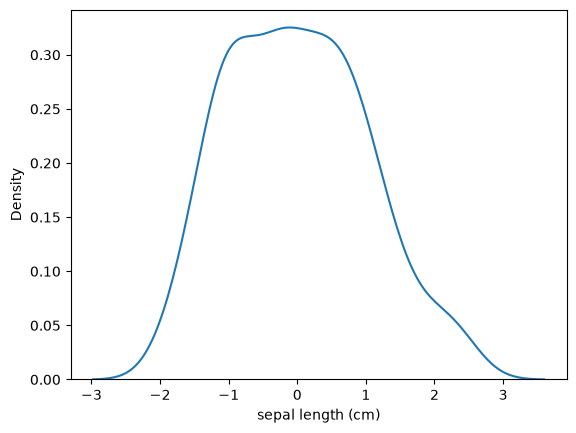

In [17]:
import seaborn as sb

sb.kdeplot(x='sepal length (cm)',data=iris_df)

grid search를 사용해 표준화, 정규화 case를 나눠서도 할 수 있다.

In [40]:

from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
 
house= pd.read_csv('data/Housing_price.csv')
house.head()

data=house.iloc[:,:5]

cat_col=['bedrooms','bathrooms','stories']
num_col=['price','area']


oh_enc=OneHotEncoder(sparse_output=False)
cat_data=oh_enc.fit_transform(data[cat_col])
cat_df=pd.DataFrame(cat_data,columns=oh_enc.get_feature_names_out())

#cat_data가 뭘 가리키는 거지?

#get_feature_name in과 out의 차이가 뭔지 모르겠다.


mm_scale=MinMaxScaler()
num_data=mm_scale.fit_transform(data[num_col])
num_df=pd.DataFrame(num_data,columns=mm_scale.feature_names_in_)

data_df=pd.concat([cat_df,num_df])

house.info()

#종속변수의 값은 scale을 해서는 안 된다.

#그러면 줄어든 값에 대해 예측함.

#회귀 예측은 '오차'가 존재한다.

#13300000 -> 1 (0.9)
#값을 되돌릴 때 오차가 커지면서, 오차의 크기가 대폭 커짐.



<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [50]:
house.dtypes[house.dtypes!='str'].index

#str이 아닌 친구들. float,int

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

In [ ]:
house=pd.read_csv('data/Housing_price.csv')
#독립변수와 종속변수 분리 
y=house['price']
X=house.drop('price',axis=1)

#범주형 수치형 데이터 분리
cat_col=X.dtypes[X.dtypes=='str'].index
num_col=X.dtypes[X.dtypes!='str'].index


#encoding
oh_enc=OneHotEncoder(sparse_output=False)

#cat_data -> 카테고리형 데이터의 인덱스를 가리킨다.
cat_data=oh_enc.fit_transform(X[cat_col])
cat_df=pd.DataFrame(cat_data,columns=oh_enc.get_feature_names_out())

print(cat_col)
print('------------')
print(oh_enc.get_feature_names_out())
#get feature names out은 기존 카테고리형 데이터의 index를
#yes or no 로 각각 만들어준다.
# guestroom -> guestroom_no , guestroom_yes

#get_feature_name out의 차이가 뭔지 모르겠다.
#X와 data의 차이가 뭐지.? 
#Scaling
mm_scale=MinMaxScaler()
num_data=mm_scale.fit_transform(X[num_col])
num_df=pd.DataFrame(num_data,columns=mm_scale.feature_names_in_)

#np.concatenate([cat_df,num_df],axis=1)
data_df=pd.concat([cat_df,num_df],axis=1)



Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')
------------
['mainroad_no' 'mainroad_yes' 'guestroom_no' 'guestroom_yes' 'basement_no'
 'basement_yes' 'hotwaterheating_no' 'hotwaterheating_yes'
 'airconditioning_no' 'airconditioning_yes' 'prefarea_no' 'prefarea_yes'
 'furnishingstatus_furnished' 'furnishingstatus_semi-furnished'
 'furnishingstatus_unfurnished']


In [69]:
#one hot encoding
X_dummies=pd.get_dummies(X)

print(X_dummies)

scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X_dummies)
print(X_scaled)

     area  bedrooms  bathrooms  stories  parking  mainroad_no  mainroad_yes  \
0    7420         4          2        3        2        False          True   
1    8960         4          4        4        3        False          True   
2    9960         3          2        2        2        False          True   
3    7500         4          2        2        3        False          True   
4    7420         4          1        2        2        False          True   
..    ...       ...        ...      ...      ...          ...           ...   
540  3000         2          1        1        2        False          True   
541  2400         3          1        1        0         True         False   
542  3620         2          1        1        0        False          True   
543  2910         3          1        1        0         True         False   
544  3850         3          1        2        0        False          True   

     guestroom_no  guestroom_yes  basement_no  base

one hot encoding + scaling을 할때, (범주형,수치형)minmax로 다 처리가 되는 이유가 뭐지?? 

1. One hot encoding을 하면 결과가 0또는 1로 나온다.
그러면 범주 말고 수치형 데이터도 one hot encoding을 사용해도 되는가?

-> 수치형 데이터는 encoding이 필요가 없나?

그리고 one hot encoding하면,어차피 0,1로 나오니까.
min max를 사용하지 않아도 된다는 뜻이었다.



2. 그리고 결과로 1,0이 아닌 0.3같은 친구들이 나오는 경우는..? 

bedroom같은 경우에는, 범주형이었는데..

정규화 이후 0.333이. 아마

2-0/6을해서 0.66인듯.

근데 얘네는 범주형이 아니니까, encoding 대상이 아니고.
그래서 이렇게 값이 나오는 거 같다.

근데 0.333으로 내버려둬도 되는건가?

In [ ]:
oh_enc=OneHotEncoder()
cat_data = oh_enc.fit_transform(X[cat_col])
print(cat_data)

#sparse matrix
''' 대각선 근처에만 1이 있고, 나머지는 0으로 가득한 행렬.
-> 공간을 너무 많이 차지한다.


coords (0,1) 칸의 값이 value다 라는 형태로 보임.
아~ 값이 0인 부분은 다 버리고, 값이 1인 부분만 배열형태로 만들었구나.

메모리.
'''





<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3815 stored elements and shape (545, 15)>
  Coords	Values
  (0, 1)	1.0
  (0, 2)	1.0
  (0, 4)	1.0
  (0, 6)	1.0
  (0, 9)	1.0
  (0, 11)	1.0
  (0, 12)	1.0
  (1, 1)	1.0
  (1, 2)	1.0
  (1, 4)	1.0
  (1, 6)	1.0
  (1, 9)	1.0
  (1, 10)	1.0
  (1, 12)	1.0
  (2, 1)	1.0
  (2, 2)	1.0
  (2, 5)	1.0
  (2, 6)	1.0
  (2, 8)	1.0
  (2, 11)	1.0
  (2, 13)	1.0
  (3, 1)	1.0
  (3, 2)	1.0
  (3, 5)	1.0
  (3, 6)	1.0
  :	:
  (541, 6)	1.0
  (541, 8)	1.0
  (541, 10)	1.0
  (541, 13)	1.0
  (542, 1)	1.0
  (542, 2)	1.0
  (542, 4)	1.0
  (542, 6)	1.0
  (542, 8)	1.0
  (542, 10)	1.0
  (542, 14)	1.0
  (543, 0)	1.0
  (543, 2)	1.0
  (543, 4)	1.0
  (543, 6)	1.0
  (543, 8)	1.0
  (543, 10)	1.0
  (543, 12)	1.0
  (544, 1)	1.0
  (544, 2)	1.0
  (544, 4)	1.0
  (544, 6)	1.0
  (544, 8)	1.0
  (544, 10)	1.0
  (544, 14)	1.0


' 대각선 근처에만 1이 있고, 나머지는 0으로 가득한 행렬.\n-> 공간을 너무 많이 차지한다.\n'